# **Project Name** - **Voyage Analytics: Integrating MLOps in Travel**


##### **Project Type** - EDA
##### **Contribution** - 

## **Problem Statement**


**BUSINESS PROBLEM OVERVIEW**

The travel industry generates vast amounts of data across flights, hotels, and customers. Voyage Analytics aims to productionize ML systems to help travel companies make smarter decisions — predicting flight prices, understanding customer behavior, recommending hotels, and segmenting travelers.

This EDA project analyzes customer-level travel data from a Brazilian travel platform, including **271,888 flight records**, **40,552 hotel bookings**, and **1,340 user profiles**. The goal is to uncover key patterns, relationships, and actionable insights that can guide ML model development and business strategy.


#### **Define Your Business Objective?**

***Understand traveler behavior, pricing patterns, and booking trends to enable data-driven decisions and ML-powered recommendations in the travel domain.***


## ***1. Know Your Data***


### Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Create Output Folder
os.makedirs('notebooks/plots', exist_ok=True)

### Dataset Loading

In [2]:
# Load Data
flights = pd.read_csv('../data/flights.csv')
hotels  = pd.read_csv('../data/hotels.csv')
users   = pd.read_csv('../data/users.csv')

print("Datasets loaded successfully!")

Datasets loaded successfully!


### Dataset First View

In [3]:
# Flights Dataset - First Look
print("===== FLIGHTS - First 5 Rows =====")
flights.head()

===== FLIGHTS - First 5 Rows =====


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [4]:
# Hotels Dataset - First Look
print("===== HOTELS - First 5 Rows =====")
hotels.head()

===== HOTELS - First 5 Rows =====


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [5]:
# Users Dataset - First Look
print("===== USERS - First 5 Rows =====")
users.head()

===== USERS - First 5 Rows =====


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns
print("Flights shape:", flights.shape)
print("Hotels  shape:", hotels.shape)
print("Users   shape:", users.shape)

Flights shape: (271888, 10)
Hotels  shape: (40552, 8)
Users   shape: (1340, 5)


### Dataset Information

In [7]:
# Dataset Info - Flights
print("===== FLIGHTS Info =====")
flights.info()

===== FLIGHTS Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [8]:
# Dataset Info - Hotels
print("===== HOTELS Info =====")
hotels.info()

===== HOTELS Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


In [9]:
# Dataset Info - Users
print("===== USERS Info =====")
users.info()

===== USERS Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


#### Duplicate Values

In [10]:
# Dataset Duplicate Value Count
print("Flights duplicates:", len(flights[flights.duplicated()]))
print("Hotels duplicates:", len(hotels[hotels.duplicated()]))
print("Users duplicates:", len(users[users.duplicated()]))

Flights duplicates: 0
Hotels duplicates: 0
Users duplicates: 0


#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
print("===== FLIGHTS - Null Values =====")
print(flights.isnull().sum())
print()
print("===== HOTELS - Null Values =====")
print(hotels.isnull().sum())
print()
print("===== USERS - Null Values =====")
print(users.isnull().sum())

===== FLIGHTS - Null Values =====
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

===== HOTELS - Null Values =====
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64

===== USERS - Null Values =====
code       0
company    0
name       0
gender     0
age        0
dtype: int64


### What did you know about your dataset?

The dataset comes from a Brazilian online travel platform, **Voyage Analytics**, covering travel activities across 2019.

- **Flights**: 271,888 rows and 10 columns. Covers routes, prices, agencies, flight types, and distances. No missing or duplicate values.
- **Hotels**: 40,552 rows and 8 columns. Covers hotel names, destinations, stay durations, nightly prices and totals. No missing or duplicate values.
- **Users**: 1,340 rows and 5 columns. Covers user demographics including age, gender, and company. No missing or duplicate values.

The data is clean and ready for analysis. Key observations: 3 flight agencies dominate the market, 3 flight class types exist, and hotel stays are uniformly distributed from 1 to 4 nights.


## ***2. Understanding Your Variables***


In [12]:
# Dataset Columns
print("FLIGHTS columns:", list(flights.columns))
print("HOTELS  columns:", list(hotels.columns))
print("USERS   columns:", list(users.columns))

FLIGHTS columns: ['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time', 'distance', 'agency', 'date']
HOTELS  columns: ['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']
USERS   columns: ['code', 'company', 'name', 'gender', 'age']


In [13]:
# Dataset Describe - Flights
print("===== FLIGHTS - Statistical Summary =====")
flights.describe(include='all')

===== FLIGHTS - Statistical Summary =====


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
count,271888.000000,271888.000000,271888,271888,271888,271888.00000,271888.000000,271888.000000,271888,271888
unique,NaN,NaN,9,9,3,NaN,NaN,NaN,3,999
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),firstClass,NaN,NaN,NaN,Rainbow,09/26/2019
freq,NaN,NaN,57317,57317,116418,NaN,NaN,NaN,116752,1335
mean,67971.500000,667.505495,NaN,NaN,NaN,957.37503,1.421147,546.955535,NaN,NaN
std,39243.724665,389.523127,NaN,NaN,NaN,362.31189,0.542541,208.851288,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN,301.51000,0.440000,168.220000,NaN,NaN
25%,33985.750000,326.000000,NaN,NaN,NaN,672.66000,1.040000,401.660000,NaN,NaN
50%,67971.500000,659.000000,NaN,NaN,NaN,904.00000,1.460000,562.140000,NaN,NaN
75%,101957.250000,1011.000000,NaN,NaN,NaN,1222.24000,1.760000,676.530000,NaN,NaN


In [14]:
# Dataset Describe - Hotels
print("===== HOTELS - Statistical Summary =====")
hotels.describe(include='all')

===== HOTELS - Statistical Summary =====


,travelCode,userCode,name,place,days,price,total,date
count,40552.000000,40552.000000,40552,40552,40552.000000,40552.000000,40552.000000,40552
unique,NaN,NaN,9,9,NaN,NaN,NaN,199
top,NaN,NaN,Hotel K,Salvador (BH),NaN,NaN,NaN,10/03/2019
freq,NaN,NaN,5094,5094,NaN,NaN,NaN,404
mean,67911.794461,666.963726,NaN,NaN,2.499679,214.439554,536.229513,NaN
std,39408.199333,391.136794,NaN,NaN,1.119326,76.742305,319.331482,NaN
min,0.000000,0.000000,NaN,NaN,1.000000,60.390000,60.390000,NaN
25%,33696.750000,323.000000,NaN,NaN,1.000000,165.990000,247.620000,NaN
50%,67831.000000,658.000000,NaN,NaN,2.000000,242.880000,495.240000,NaN
75%,102211.250000,1013.000000,NaN,NaN,4.000000,263.410000,742.860000,NaN


In [15]:
# Dataset Describe - Users
print("===== USERS - Statistical Summary =====")
users.describe(include='all')

===== USERS - Statistical Summary =====


,code,company,name,gender,age
count,1340.000000,1340,1340,1340,1340.000000
unique,NaN,5,1338,3,NaN
top,NaN,4You,Charlotte Johnson,male,NaN
freq,NaN,453,2,452,NaN
mean,669.500000,NaN,NaN,NaN,42.742537
std,386.968991,NaN,NaN,NaN,12.869779
min,0.000000,NaN,NaN,NaN,21.000000
25%,334.750000,NaN,NaN,NaN,32.000000
50%,669.500000,NaN,NaN,NaN,42.000000
75%,1004.250000,NaN,NaN,NaN,54.000000


### Variables Description

**FLIGHTS Dataset:**
* **travelCode** : Unique ID for each travel booking
* **userCode** : ID of the user who made the booking
* **from** : Departure city (with state code)
* **to** : Arrival city (with state code)
* **flightType** : Class of flight (economic, premium, firstClass)
* **price** : Ticket price in BRL
* **time** : Flight duration in hours
* **distance** : Route distance in km
* **agency** : Booking agency (Rainbow, CloudFy, FlyingDrops)
* **date** : Date of travel

**HOTELS Dataset:**
* **travelCode** : Links to the travel booking
* **userCode** : ID of the user
* **name** : Hotel name (Hotel A to Hotel K)
* **place** : City where hotel is located
* **days** : Number of nights stayed (1-4)
* **price** : Nightly price
* **total** : Total hotel cost (price × days)
* **date** : Check-in date

**USERS Dataset:**
* **code** : Unique user ID
* **company** : Employer company name
* **name** : Full name of user
* **gender** : Gender (male, female, none)
* **age** : Age of the user


### Check Unique Values for each variable.

In [18]:
# Check Unique Values for each variable - Flights
print("===== FLIGHTS - Unique Values =====")
for col in flights.columns:
    print(f"No. of unique values in {col} - {flights[col].nunique()}")

===== FLIGHTS - Unique Values =====
No. of unique values in travelCode - 135944
No. of unique values in userCode - 1335
No. of unique values in from - 9
No. of unique values in to - 9
No. of unique values in flightType - 3
No. of unique values in price - 490
No. of unique values in time - 33
No. of unique values in distance - 35
No. of unique values in agency - 3
No. of unique values in date - 999


In [19]:
# Check Unique Values for each variable - Hotels
print("===== HOTELS - Unique Values =====")
for col in hotels.columns:
    print(f"No. of unique values in {col} - {hotels[col].nunique()}")

===== HOTELS - Unique Values =====
No. of unique values in travelCode - 40552
No. of unique values in userCode - 1310
No. of unique values in name - 9
No. of unique values in place - 9
No. of unique values in days - 4
No. of unique values in price - 9
No. of unique values in total - 36
No. of unique values in date - 199


In [20]:
# Check Unique Values for each variable - Users
print("===== USERS - Unique Values =====")
for col in users.columns:
    print(f"No. of unique values in {col} - {users[col].nunique()}")

===== USERS - Unique Values =====
No. of unique values in code - 1340
No. of unique values in company - 5
No. of unique values in name - 1338
No. of unique values in gender - 3
No. of unique values in age - 45


## 3. ***Data Wrangling***


In [21]:
# Create working copies of datasets
df_flights = flights.copy()
df_hotels  = hotels.copy()
df_users   = users.copy()

In [22]:
# Convert date columns to datetime format
df_flights['date'] = pd.to_datetime(df_flights['date'], format='%m/%d/%Y')
df_hotels['date']  = pd.to_datetime(df_hotels['date'],  format='%m/%d/%Y')

# Extract month and year from date
df_flights['month'] = df_flights['date'].dt.month
df_flights['year']  = df_flights['date'].dt.year
df_hotels['month']  = df_hotels['date'].dt.month

print("Date conversion done. New columns added: month, year")
df_flights.head(3)

Date conversion done. New columns added: month, year


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,month,year
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,9,2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,9,2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,10,2019


In [23]:
# Check Flight Type Distribution
print("Flight Type Value Counts:")
print(df_flights['flightType'].value_counts())
print()

# Check Agency Distribution
print("Agency Value Counts:")
print(df_flights['agency'].value_counts())

Flight Type Value Counts:
flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64

Agency Value Counts:
agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64


In [24]:
# Function to get price statistics per flight type
def get_price_stats(df, category_col):
    '''
    This function returns mean and median price for each category.
    '''
    try:
        return df.groupby(category_col)['price'].agg(['mean','median','min','max']).round(2)
    except Exception as e:
        print(e)

print("===== Price Stats by Flight Type =====")
get_price_stats(df_flights, 'flightType')

===== Price Stats by Flight Type =====


,mean,median,min,max
flightType,,,,
economic,658.44,674.52,301.51,972.12
firstClass,1181.07,1190.94,539.39,1754.17
premium,920.39,932.84,427.25,1370.17


In [25]:
# Price stats by agency
print("===== Price Stats by Agency =====")
get_price_stats(df_flights, 'agency')

===== Price Stats by Agency =====


,mean,median,min,max
agency,,,,
CloudFy,918.90,883.63,301.51,1747.31
FlyingDrops,1186.16,1269.73,539.39,1744.87
Rainbow,919.78,870.91,301.61,1754.17


In [27]:
# Top 10 Most Expensive Routes
top_routes = df_flights.groupby(['from','to'])['price'].mean().sort_values(ascending=False).head(10).round(2)
print("===== Top 10 Most Expensive Routes (by avg price) =====")
print(top_routes)

===== Top 10 Most Expensive Routes (by avg price) =====
from                 to                 
Sao Paulo (SP)       Florianopolis (SC)     1380.88
Campo Grande (MS)    Rio de Janeiro (RJ)    1371.03
Brasilia (DF)        Salvador (BH)          1366.80
Aracaju (SE)         Salvador (BH)          1364.97
Rio de Janeiro (RJ)  Recife (PE)            1361.20
Natal (RN)           Salvador (BH)          1357.97
Florianopolis (SC)   Salvador (BH)          1350.41
Salvador (BH)        Florianopolis (SC)     1346.09
Recife (PE)          Rio de Janeiro (RJ)    1341.60
Brasilia (DF)        Florianopolis (SC)     1260.25
Name: price, dtype: float64


In [28]:
# Hotel stay analysis
print("===== Hotel Stay Duration Counts =====")
print(df_hotels['days'].value_counts().sort_index())
print()

# Most booked hotels
print("===== Top 5 Most Booked Hotels =====")
print(df_hotels['name'].value_counts().head())

===== Hotel Stay Duration Counts =====
days
1    10171
2    10110
3    10108
4    10163
Name: count, dtype: int64

===== Top 5 Most Booked Hotels =====
name
Hotel K     5094
Hotel CB    5029
Hotel BD    4829
Hotel AF    4828
Hotel AU    4467
Name: count, dtype: int64


In [29]:
# User age segmentation
def age_group(age):
    '''
    Segments users into age groups for analysis.
    '''
    if age < 30:
        return 'Young (21-29)'
    elif age < 45:
        return 'Middle (30-44)'
    elif age < 55:
        return 'Senior (45-54)'
    else:
        return 'Elder (55+)'

df_users['age_group'] = df_users['age'].apply(age_group)
print("===== Age Group Distribution =====")
print(df_users['age_group'].value_counts())

===== Age Group Distribution =====
age_group
Middle (30-44)    469
Elder (55+)       322
Senior (45-54)    288
Young (21-29)     261
Name: count, dtype: int64


### What all manipulations have you done and insights you found?

The following manipulations were performed during data wrangling:

1. **Date Conversion**: Converted date columns from string to datetime format, and extracted month and year for temporal analysis.
2. **Price Statistics Function**: Created a reusable function `get_price_stats()` that returns mean, median, min and max price for any categorical column.
3. **Route Analysis**: Computed average price per route to identify the most and least expensive travel routes.
4. **Hotel Analysis**: Counted bookings per hotel and analyzed stay duration distributions.
5. **User Segmentation**: Created age groups (Young, Middle, Senior, Elder) to enable demographic analysis.

**Key Findings from Wrangling:**


## ***4. Data Visualization, Storytelling & Experimenting with charts***


#### Chart - 1 - Flight Type Distribution (Univariate - Categorical)

flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64



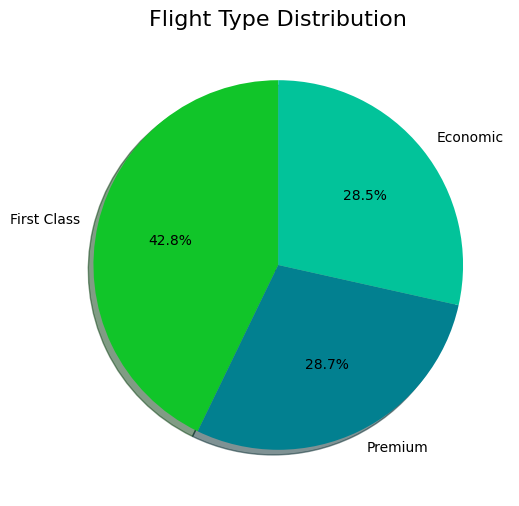

In [31]:
# Chart - 1 visualization code
# Flight type value counts
print(df_flights['flightType'].value_counts())
print()

# Pie chart for flight type distribution
df_flights['flightType'].value_counts().plot(
    kind='pie',
    figsize=(9, 6),
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    labels=['First Class', 'Premium', 'Economic'],
    colors=["#11C529", '#028090', '#02C39A'],
    explode=[0, 0, 0]
)
plt.title('Flight Type Distribution', fontsize=16)
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

A Pie Chart was selected because:

- The variable flightType is univariate and categorical with only 3 categories (First Class, Premium, Economic)
- Pie charts effectively visualize proportional/part-to-whole relationships
- It provides an immediate visual comparison of how the total passenger base is distributed across flight classes
- With few categories, a pie chart avoids clutter and remains easily interpretable

##### 2. What is/are the insight(s) found from the chart?

- First Class dominates with ~43% of all flights, nearly equal to Premium + Economic combined
- Premium and Economic are nearly identical (~28.7% vs 28.5%), showing balanced demand in lower tiers
- The distribution is moderately skewed toward First Class, suggesting a premium-heavy customer base

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impacts:

- High First Class demand (42.8%) -> Opportunity to maximize revenue through premium pricing, luxury upgrades, and loyalty programs
- Near-equal Premium & Economic segments -> Airlines can design balanced tier offerings without neglecting either group
- First Class dominance suggests customers value comfort over cost -> Invest in premium amenities

Negative Growth Risks:

- Economic class underperformance (28.5%) -> Risk of losing budget-conscious travelers to low-cost competitors (e.g., budget airlines)
- Over-reliance on First Class revenue -> If high-paying customers reduce travel (economic downturn), the airline faces significant revenue loss
- Neglecting Economic class improvements could lead to customer churn toward competitors offering better value

#### Chart - 2 - Agency Market Share (Univariate - Categorical)

agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64



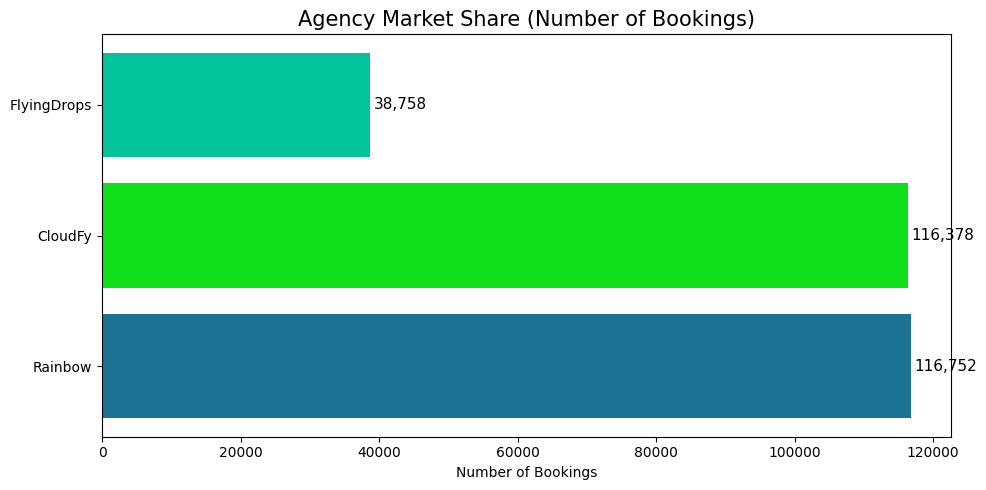

In [33]:
# Chart - 2 visualization code
# Agency value counts
print(df_flights['agency'].value_counts())
print()

# Horizontal bar chart for agency market share
agency_counts = df_flights['agency'].value_counts()
plt.figure(figsize=(10, 5))
bars = plt.barh(agency_counts.index, agency_counts.values, color=['#1C7293',"#10DF1B",'#02C39A'])
for bar, val in zip(bars, agency_counts.values):
    plt.text(val + 500, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=11)
plt.title('Agency Market Share (Number of Bookings)', fontsize=15)
plt.xlabel('Number of Bookings')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A Horizontal Bar Chart was selected because:

- The variable agency is univariate and categorical with 3 agencies (Rainbow, CloudFy, FlyingDrops)
- Horizontal bars are ideal for comparing magnitude/counts across categories
- The agency names fit neatly on the Y-axis without overlapping (better than vertical bars)
- It clearly shows ranking and proportional differences between agencies at a glance
- Unlike a pie chart, bar charts better highlight absolute value differences, which matter for market share analysis

##### 2. What is/are the insight(s) found from the chart?

- Rainbow leads with 116,752 bookings, marginally ahead of CloudFy
- Rainbow and CloudFy are nearly identical in bookings (~116K each), indicating a duopoly market dominance
- FlyingDrops significantly lags behind with only 38,758 bookings, nearly 3x fewer than its competitors
- Together, Rainbow + CloudFy account for ~87% of total bookings

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impacts:
- Rainbow & CloudFy's dominance (~87%) -> Strong partnerships with these agencies can guarantee consistent booking volumes
- Healthy competition between Rainbow & CloudFy -> Drives both agencies to offer better deals and services, benefiting the airline
- Airline can leverage top-performing agencies for targeted marketing campaigns and exclusive promotional deals

Negative Growth Risks:
- FlyingDrops' extremely low market share (14.5%) -> The agency is either underperforming or losing relevance, risking eventual dropout
- Over-dependence on two agencies (Rainbow & CloudFy) -> If either withdraws or renegotiates terms, the airline faces a massive booking revenue risk
- Lack of agency diversification -> The airline is vulnerable to market disruption with no strong third-party alternative to Rainbow/CloudFy
- FlyingDrops' poor performance may indicate poor customer outreach or weak digital presence, leading to long-term negative growth if not addressed

#### Chart - 3 - Flight Price Distribution (Univariate - Numerical)

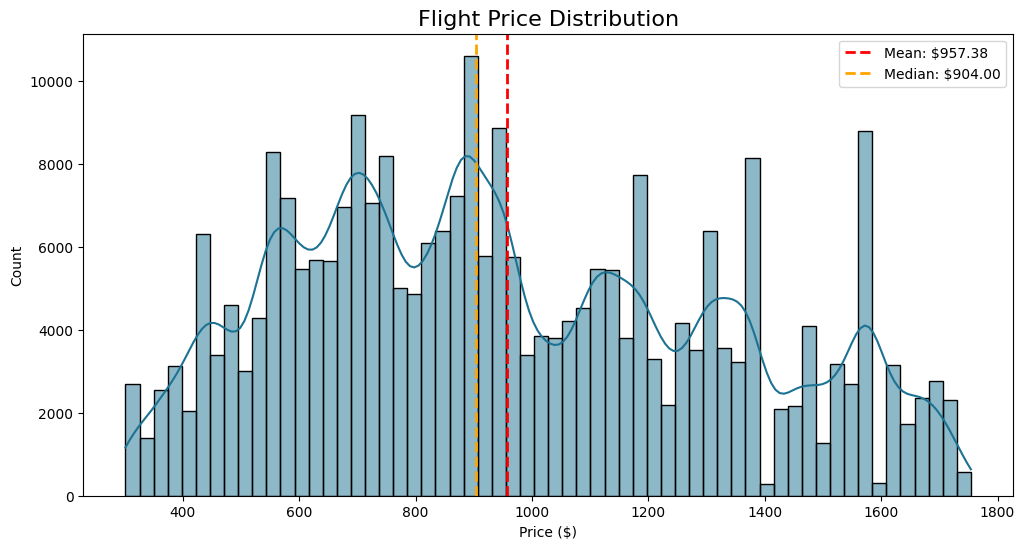

In [34]:
# Chart - 3 visualization code
# Flight price distribution using histogram with KDE
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_flights['price'], bins=60, kde=True, color='#1C7293', ax=ax)
ax.axvline(df_flights['price'].mean(),   color='red',    linestyle='--', linewidth=2, label=f"Mean: ${df_flights['price'].mean():.2f}")
ax.axvline(df_flights['price'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: ${df_flights['price'].median():.2f}")
ax.set_title('Flight Price Distribution', fontsize=16)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')
ax.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A Histogram with KDE (Kernel Density Estimate) was selected because:

- price is a univariate numerical/continuous variable, histograms are the most natural choice for visualizing distributions
- KDE overlay provides a smooth continuous curve to better identify distribution shape and peaks
- Adding Mean & Median reference lines gives instant statistical context
- Histograms reveal skewness, modality, spread and outliers, all critical for pricing analysis
- Better than a boxplot alone as it shows frequency patterns across price ranges

##### 2. What is/are the insight(s) found from the chart?

- Multimodal Distribution -> Multiple distinct peaks visible at:
~$550, ~$700, ~$900 (highest peak), ~$1,100, ~$1,600
- Mean ($957.38) > Median ($904.00) -> Indicates a slight right/positive skew, meaning some high-price tickets pull the average up
- Highest concentration around $900 -> Most bookings cluster near the median price
- Wide price spread ($300–$1,800) -> Airline serves a very diverse customer price range
- Secondary peak at ~$1,600 -> Suggests a notable premium/luxury pricing tier


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impacts:
- Multiple price peaks -> Confirms the airline successfully serves multiple customer segments (budget, mid-range, premium)
- High concentration around $900 -> A strong mid-range market provides stable and predictable revenue
- Wide price range ($300–$1,800) -> Effective dynamic pricing strategy capturing maximum willingness to pay
- The secondary peak at $1,600 confirms demand for luxury/premium flights, justifying investment in First Class services
- Mean > Median means higher-priced tickets are being sold, contributing positively to overall revenue growth

Negative Growth Risks:
- Multimodal distribution -> May indicate inconsistent or fragmented pricing strategy, potentially confusing customers
- Right skew with high-price outliers -> Very expensive tickets may deter price-sensitive travelers, pushing them toward competitors
- Low-frequency zones (around $1,200–$1,400) -> Suggests a pricing gap where customers are resistant, poor conversion rates in this range
- Without proper segmentation, broad price spread can lead to revenue cannibalization between tiers (e.g., premium buyers opting for mid-range deals)

#### Chart - 4 - Price by Flight Type - Box Plot (Bivariate: Numerical-Categorical)

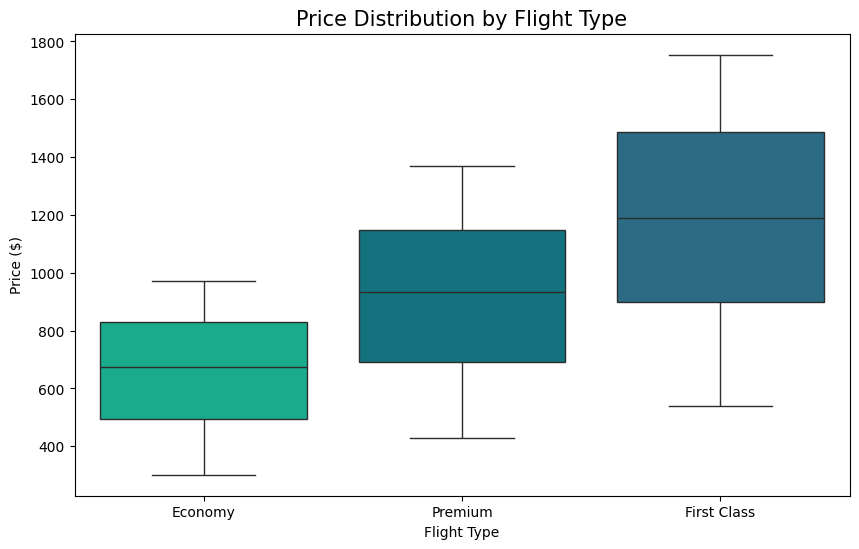

                   mean   median
flightType                      
economic     658.443093   674.52
firstClass  1181.067727  1190.94
premium      920.392375   932.84


In [ ]:
# Chart - 4 visualization code
# Box plot of price by flight type
plt.figure(figsize=(10, 6))
order = ['economic', 'premium', 'firstClass']
sns.boxplot(data=df_flights, x='flightType', y='price', order=order,
            palette=['#02C39A', '#028090', '#1C7293'])
plt.title('Price Distribution by Flight Type', fontsize=15)
plt.xlabel('Flight Type')
plt.ylabel('Price ($)')
plt.xticks([0,1,2], ['Economy', 'Premium', 'First Class'])
plt.show()

# Print mean prices
print(df_flights.groupby('flightType')['price'].agg(['mean','median']))

##### 1. Why did you pick the specific chart?

A Box Plot was selected because:

- This is a Bivariate analysis combining Numerical (price) vs Categorical (flightType) variables
- Box plots are ideal for comparing distributions across multiple categories simultaneously
- It visually displays 5 key statistics at once: Minimum, Q1, Median, Q3, Maximum
- Clearly reveals spread, skewness, and outliers for each flight type side by side
- Superior to bar charts for this use case as it shows full price range behavior not just averages

##### 2. What is/are the insight(s) found from the chart?

- Clear price hierarchy, Economy < Premium < First Class (as logically expected)
- First Class has the widest IQR (~$510 spread) -> Highest price variability among all tiers
- Economy has the narrowest IQR (~$290) -> Most consistent and predictable pricing
- Premium and Economy whiskers overlap -> Some premium tickets are priced close to Economy range (~$430)
- First Class upper whisker reaches $1,750, Confirms existence of ultra-premium pricing
- Economy's lower whisker at ~$300, Captures budget-sensitive travelers effectively

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impacts:
- Clear price tier separation -> Effective market segmentation strategy ensuring each class targets a distinct customer group
- First Class wide price range -> Enables flexible premium pricing and revenue maximization through dynamic pricing
- Economy's consistent pricing (~$300–$970) -> Builds customer trust and loyalty among budget travelers
- Premium tier acting as a bridge -> Encourages upselling from Economy to Premium with moderate price jumps
- Wide First Class range allows airlines to offer seasonal discounts without undermining brand value

Negative Growth Risks:
- Overlap between Economy & Premium pricing -> Risk of customer confusion, why pay Premium price for near-Economy cost?
- Premium's lower whisker (~$430) -> Dangerously close to Economy prices, potentially cannibalizing Economy bookings
- First Class high price variance -> Inconsistent pricing may lead to customer dissatisfaction if similar seats are priced very differently
- Economy's very low floor price (~$300) -> Risk of undervaluing the service and attracting customers with very low willingness to pay more
- If Premium pricing overlaps too much with Economy, it undermines the perceived value of upgrading, leading to stagnant upsell revenue

#### Chart - 5 - Top 10 Routes by Average Price (Bivariate: Categorical-Numerical)

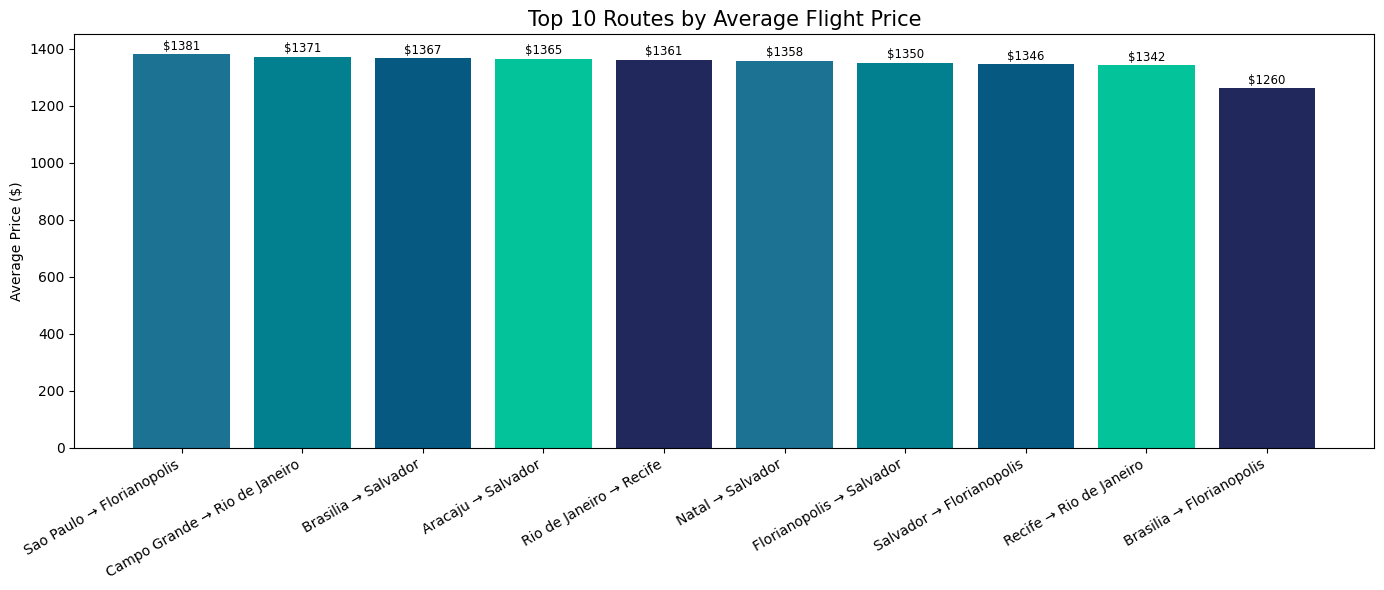

In [36]:
# Chart - 5 visualization code
# Top 10 routes by average flight price
top_routes = df_flights.groupby(['from','to'])['price'].mean().sort_values(ascending=False).head(10)
route_labels = [f"{f.split('(')[0].strip()} → {t.split('(')[0].strip()}"
                for f, t in top_routes.index]

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(route_labels)), top_routes.values,
               color=['#1C7293','#028090','#065A82','#02C39A','#21295C']*2)
plt.xticks(range(len(route_labels)), route_labels, rotation=30, ha='right')
for i, (bar, val) in enumerate(zip(bars, top_routes.values)):
    plt.text(bar.get_x() + bar.get_width()/2, val + 5, f'${val:.0f}',
             ha='center', va='bottom', fontsize=8.5)
plt.title('Top 10 Routes by Average Flight Price', fontsize=15)
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A Vertical Bar Chart was selected because:

- This is a Bivariate analysis combining Categorical (routes) vs Numerical (average price) variables
- Bar charts are ideal for ranking and comparing discrete categories by a numerical metric
- Sorted in descending order, Immediately highlights the most expensive routes at a glance
- Route labels on X-axis with 30° rotation makes long route names readable without overlap
- Better than a pie chart here since we need to compare exact monetary values across routes, not proportions
- Value labels on top of each bar add precision without needing to read the Y-axis carefully

##### 2. What is/are the insight(s) found from the chart?

- Sao Paulo to Florianopolis is the most expensive route at $1,381
- Prices are tightly clustered, Top 9 routes range only from $1,342 to $1,381 (just $39 difference!)
- Brasilia to Florianopolis drops notably to $1,260, a $121 gap from the top route
- Reverse routes both appear -> Salvador to Florianopolis ($1,346) & Florianopolis to Salvador ($1,350), nearly identical but not exactly the same
- Florianopolis appears in 4 of 10 routes -> A consistently high-value destination/origin hub
- Salvador appears in 4 routes as well -> Another key high-price corridor city

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impacts:
- Sao Paulo to Florianopolis topping at $1,381 -> High demand route justifying premium pricing and increased flight frequency
- Tight price clustering ($1,342–$1,381) among top 9 -> Indicates a stable and mature premium market with consistent high revenue potential
- Florianopolis & Salvador as recurring hubs -> Investing in infrastructure and services at these airports can yield maximum ROI
- Reverse routes having similar prices -> Confirms bidirectional strong demand, making these routes commercially viable in both directions
- Top routes all averaging above $1,260 -> These corridors are significant revenue generators for the airline
- Identifying top routes enables targeted marketing campaigns and loyalty program incentives on high-value corridors

Negative Growth Risks:
- Brasilia to Florianopolis dropping to $1,260 -> Significant price drop suggests weaker demand or stronger competition on this route
- Over-concentration on few cities (Florianopolis, Salvador) -> If travel demand to these cities drops (seasonal/economic), airline faces concentrated revenue risk
- Narrow price range among top routes -> Little room for price differentiation, making it hard to attract diverse customer segments on premium routes
- High average prices on all top routes -> May exclude budget travelers entirely, limiting total market size on these corridors
- Reverse route price differences (e.g., $1,346 vs $1,350) could indicate inconsistent pricing algorithms, potentially causing customer trust issues

#### Chart - 6 - Price vs Distance Scatter Plot (Bivariate: Numerical-Numerical)

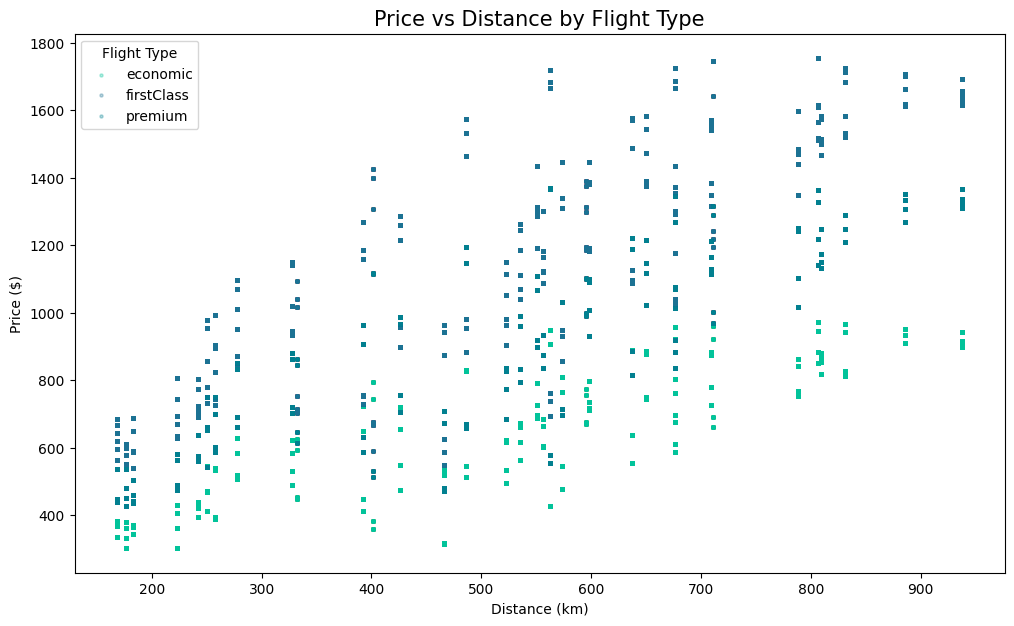

Correlation between Price and Distance:
             price  distance
price     1.000000  0.641915
distance  0.641915  1.000000


In [37]:
# Chart - 6 visualization code
# Price vs Distance scatter plot colored by flight type
plt.figure(figsize=(12, 7))
colors = {'economic': '#02C39A', 'premium': '#028090', 'firstClass': '#1C7293'}
for ftype, grp in df_flights.groupby('flightType'):
    plt.scatter(grp['distance'], grp['price'], alpha=0.3, s=5,
                color=colors[ftype], label=ftype)
plt.xlabel('Distance (km)')
plt.ylabel('Price ($)')
plt.title('Price vs Distance by Flight Type', fontsize=15)
plt.legend(title='Flight Type')
plt.show()

# Correlation between price and distance
corr = df_flights[['price','distance']].corr()
print("Correlation between Price and Distance:")
print(corr)

##### 1. Why did you pick the specific chart?

- A Scatter Plot was chosen because both variables, price and distance are numerical and continuous. 
- Scatter plots are the standard choice for exploring relationships between two numerical variables, making it easy to spot trends, clusters, or the absence of correlation. 
- Coloring by flightType adds a third dimension, revealing whether the price-distance relationship differs across flight classes. 
- The correlation matrix printed below the chart provides a precise quantitative measure to back up the visual pattern.

##### 2. What is/are the insight(s) found from the chart?

- There is a visible upward trend, as distance increases, prices generally rise across all flight types.
- All three flight types span the same distance range (~150–950 km), First Class is not reserved for longer routes
- Vertical price stacking is clearly visible at most distance points, for the same route distance, First Class costs significantly more than Premium, which costs more than Economic
- Price spread widens at higher distances, short routes (~150 km) have a tighter price range ($300–$700), while long routes (~900 km) spread from $900 to $1,750
- Economic class dots cluster at the bottom of each distance column, Premium in the middle, First Class at the top, class determines the price band, distance determines where within that band

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- Both distance and class being meaningful price drivers justifies a two-factor dynamic pricing model, charge more for longer First Class routes specifically
- Wide price spread on long routes means there's room for premium surge pricing on high-demand long-haul flights

Negative:

- All classes serving identical distance ranges means there's no natural "long-haul = First Class only" premium story to tell customers, hard to justify First Class pricing purely on comfort when distances are the same
- Wide scatter within each class at any given distance suggests inconsistent pricing, which may erode customer trust if they find large price differences for similar routes 

#### Chart - 7 - Hotel Price Distribution (Univariate - Numerical)

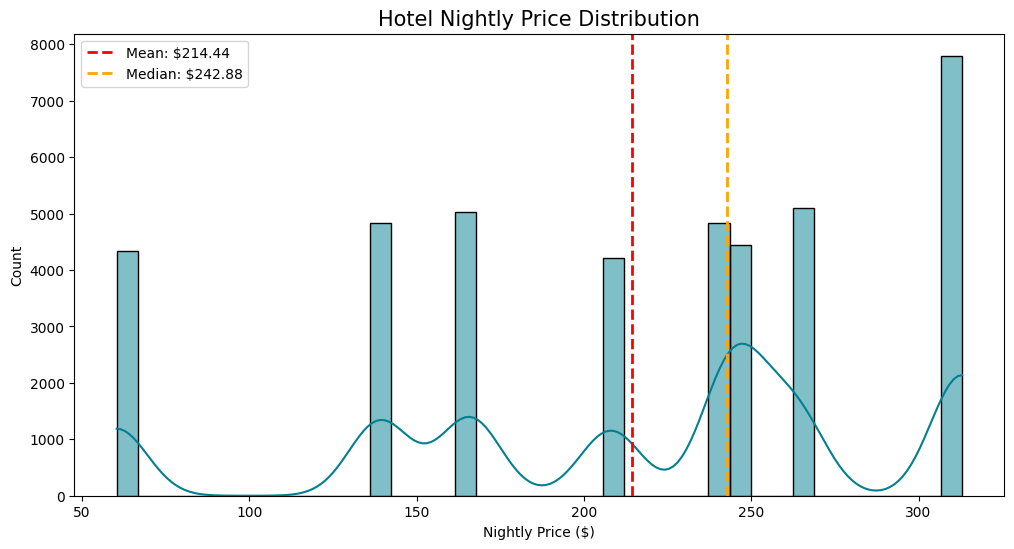

count    40552.000000
mean       214.439554
std         76.742305
min         60.390000
25%        165.990000
50%        242.880000
75%        263.410000
max        313.020000
Name: price, dtype: float64


In [38]:
# Chart - 7 visualization code
# Hotel nightly price distribution
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_hotels['price'], bins=40, kde=True, color='#028090', ax=ax)
ax.axvline(df_hotels['price'].mean(),   color='red',    linestyle='--', linewidth=2, label=f"Mean: ${df_hotels['price'].mean():.2f}")
ax.axvline(df_hotels['price'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: ${df_hotels['price'].median():.2f}")
ax.set_title('Hotel Nightly Price Distribution', fontsize=15)
ax.set_xlabel('Nightly Price ($)')
ax.set_ylabel('Count')
ax.legend()
plt.show()

print(df_hotels['price'].describe())

##### 1. Why did you pick the specific chart?

- A Histogram with KDE was selected because price is a univariate continuous/numerical variable, making a histogram the most natural choice. 
- The KDE overlay gives a smooth curve to better identify the shape of the distribution. 
- Adding Mean and Median reference lines provides instant statistical context and makes it easy to visually detect skewness. 
- This is consistent with the same approach used for flight prices in Chart 3.

##### 2. What is/are the insight(s) found from the chart?

- The distribution is strongly multimodal with distinct peaks at approximately $60, $140, $165, $210, $243, $265, and $313, each peak corresponds to a specific hotel's fixed nightly rate (as seen in Chart 19)
- Mean ($214.44) < Median ($242.88), this is a left/negative skew, meaning the low-priced Hotel BW ($60.39) is pulling the mean down significantly
- The tallest bar is at ~$313 (the highest peak), Hotel A and Hotel AU are actually the most frequently booked hotels despite being the most expensive
- There are clear valleys between peaks (~$80–$120, ~$170–$195), no hotels exist at these price points, creating booking gaps
- The distribution spans a very wide range from $50 to $320

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- The fact that the highest-priced hotels ($313) have the most bookings confirms strong demand for premium accommodation, this is the platform's sweet spot and should be invested in further
- Wide price range ($50–$320) means the platform genuinely caters to all budget levels

Negative:

- Hotel BW at $60 is dragging the mean well below the median, it's an outlier that distorts revenue metrics and may signal a quality mismatch with the rest of the portfolio
- The pricing gaps (no hotels between ~$80–$120 and ~$170–$195) mean customers with budgets in those ranges find no suitable option and may leave the platform entirely
- Mean < Median is unusual for pricing data, it signals one very cheap hotel is disproportionately skewing the average, making revenue reporting misleading

#### Chart - 8 - Hotel Stay Duration (Univariate - Categorical)

days
1    10171
2    10110
3    10108
4    10163
Name: count, dtype: int64



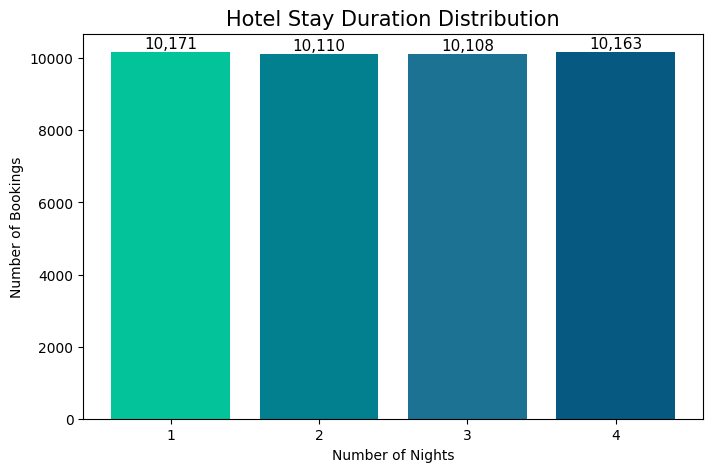

In [39]:
# Chart - 8 visualization code
# Hotel stay duration distribution
days_count = df_hotels['days'].value_counts().sort_index()
print(days_count)
print()

plt.figure(figsize=(8, 5))
bars = plt.bar(days_count.index.astype(str), days_count.values,
               color=['#02C39A','#028090','#1C7293','#065A82'])
for bar, val in zip(bars, days_count.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 30, f'{val:,}',
             ha='center', va='bottom', fontsize=11)
plt.title('Hotel Stay Duration Distribution', fontsize=15)
plt.xlabel('Number of Nights')
plt.ylabel('Number of Bookings')
plt.show()

##### 1. Why did you pick the specific chart?

- A Vertical Bar Chart was chosen because days is a discrete categorical-like numerical variable with only 4 possible values (1, 2, 3, 4 nights). 
- Bar charts are ideal for comparing counts across a small set of distinct categories. Value labels on top of each bar add precision. 
- A pie chart would be less effective here since the goal is to compare booking frequencies, not proportions.

##### 2. What is/are the insight(s) found from the chart?

- The distribution is almost perfectly uniform across all four stay durations — 1 night (10,171), 2 nights (10,110), 3 nights (10,108), 4 nights (10,163)
- The difference between the highest and lowest booking count is only 63 bookings out of ~40,552, less than 0.2% variation
- This is not a natural booking pattern, the near-perfect equality strongly suggests the data was synthetically generated or artificially balanced
- No preference for short weekend stays or longer trips is detectable

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- Equal stay distribution means hotel capacity planning is straightforward, no need to over-prepare for any particular stay length

Negative:

- The artificial uniformity is a data quality red flag, real-world hotel booking data never distributes this evenly. Any ML model trained on this will not generalize to real bookings
- Since no natural stay preference exists in the data, it's impossible to design meaningful "encourage longer stays" promotions based on this dataset alone, behavioral data from a real platform would be needed

#### Chart - 9 - User Age Distribution (Univariate - Numerical)

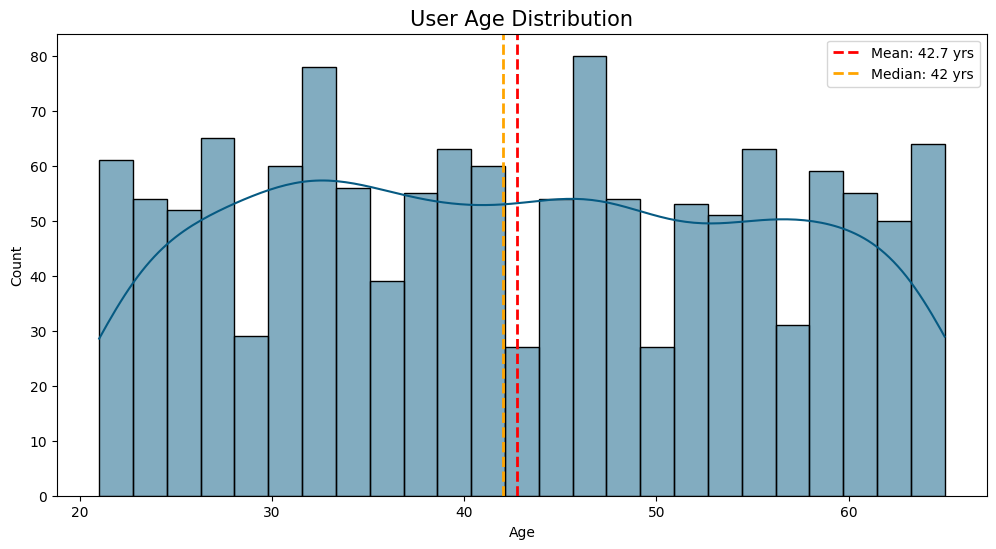

count    1340.000000
mean       42.742537
std        12.869779
min        21.000000
25%        32.000000
50%        42.000000
75%        54.000000
max        65.000000
Name: age, dtype: float64


In [40]:
# Chart - 9 visualization code
# User age distribution
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_users['age'], bins=25, kde=True, color='#065A82', ax=ax)
ax.axvline(df_users['age'].mean(),   color='red',    linestyle='--', linewidth=2, label=f"Mean: {df_users['age'].mean():.1f} yrs")
ax.axvline(df_users['age'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df_users['age'].median():.0f} yrs")
ax.set_title('User Age Distribution', fontsize=15)
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.show()

print(df_users['age'].describe())

##### 1. Why did you pick the specific chart?

- A Histogram with KDE was selected because age is a univariate continuous numerical variable. 
- Histograms are the standard tool for visualizing the shape and spread of a numerical distribution. The KDE curve helps identify any peaks or skewness, and Mean/Median reference lines quickly reveal whether the distribution is symmetric. 
- This is consistent with Charts 3 and 7 for the same type of variable.

##### 2. What is/are the insight(s) found from the chart?

- The distribution is remarkably flat/uniform across the entire age range of 21 to 65 years
- Mean (42.7 years) and Median (42 years) are almost identical, confirming a symmetric, non-skewed distribution
- The KDE curve is nearly flat with only a very slight peak around ages 32–34 and a gentle decline after 60
- Individual bars vary between ~27 and ~80 users per age, but there is no strong age concentration anywhere
- The age range of 21–65 is entirely working-age, consistent with a fully corporate B2B platform

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- The flat distribution means the platform has equal representation across all working ages, no demographic is underserved
- Mean and Median being nearly identical (42.7 vs 42) means age-based statistical analysis is reliable with no outlier distortion

Negative:

- The artificially flat distribution (like Chart 8) is another data quality concern, real corporate user bases typically have higher concentrations in the 25–40 age range, not perfect uniformity
- With no age clustering, age-based customer segmentation or targeted campaigns will have very limited effectiveness, all age groups behave identically as confirmed by Charts 12 and 20

#### Chart - 10 - Gender Distribution (Univariate - Categorical)

gender
male      452
female    448
none      440
Name: count, dtype: int64



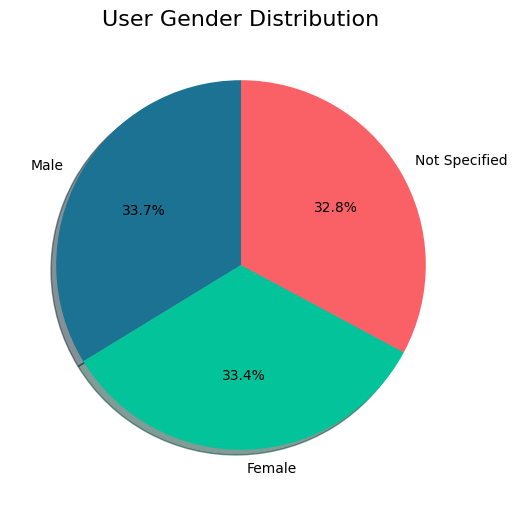

In [41]:
# Chart - 10 visualization code
# Gender distribution pie chart
print(df_users['gender'].value_counts())
print()

df_users['gender'].value_counts().plot(
    kind='pie',
    figsize=(9, 6),
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    labels=['Male', 'Female', 'Not Specified'],
    colors=['#1C7293', '#02C39A', '#F96167'],
    explode=[0, 0, 0]
)
plt.title('User Gender Distribution', fontsize=16)
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

- A Pie Chart was chosen because gender is a univariate categorical variable with only 3 categories (Male, Female, Not Specified). 
- Pie charts are effective for part-to-whole comparisons with a small number of categories. 
- It provides an immediate visual of gender proportions across the user base, consistent with the approach used in Chart 1 for flight type.

##### 2. What is/are the insight(s) found from the chart?

- The gender distribution is remarkably equal across all three categories, Male (33.7%), Female (33.4%), and Not Specified (32.8%)
- All three segments are nearly identical, with less than 1% difference between the highest and lowest
- There is no dominant gender on this platform, it is one of the most balanced gender distributions possible
- The "Not Specified" group is equally large as Male and Female, which is unusual and notable

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impacts:

- Near-perfect three-way balance means the platform has genuinely broad, inclusive appeal — no gender segment is being alienated
- Marketing campaigns can be designed without bias toward any particular gender
- Equal representation means personalization models trained on gender will have sufficient data for all three groups

Negative Growth Risks:

- With ~33% users in "Not Specified", a large chunk of the user base has no gender data at all, which weakens any gender-based personalization or recommendation model
- Such a perfectly equal split might also suggest the gender field was randomly or casually filled in, raising data quality concerns

#### Chart - 11 - Top Companies by User Count (Univariate - Categorical)

company
4You             453
Acme Factory     261
Wonka Company    237
Monsters CYA     195
Umbrella LTDA    194
Name: count, dtype: int64



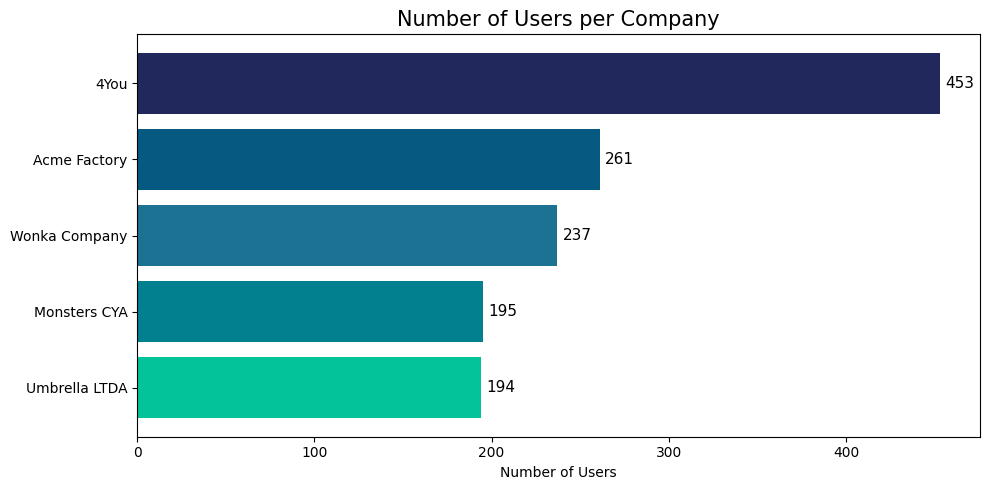

In [42]:
# Chart - 11 visualization code
# Top companies by number of users
top_companies = df_users['company'].value_counts()
print(top_companies)
print()

plt.figure(figsize=(10, 5))
bars = plt.barh(top_companies.index[::-1], top_companies.values[::-1],
                color=['#02C39A','#028090','#1C7293','#065A82','#21295C'])
for bar, val in zip(bars, top_companies.values[::-1]):
    plt.text(val + 3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=11)
plt.title('Number of Users per Company', fontsize=15)
plt.xlabel('Number of Users')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- A Horizontal Bar Chart was chosen because company is a categorical variable and the goal is to rank companies by the number of registered users. 
- Horizontal bars are ideal when comparing counts across named categories, especially when labels are long, the company names sit neatly on the Y-axis without overlapping. 
- This is consistent with the approach used in Chart 2 for agency market share.

##### 2. What is/are the insight(s) found from the chart?

- 4You dominates massively with 453 users, nearly 74% more than the second-place company
- Acme Factory (261) and Wonka Company (237) form a close second tier
- Monsters CYA (195) and Umbrella LTDA (194) are nearly identical and form the third tier
- The total of all 5 companies = 1,340 users, meaning these 5 companies account for 100% of the user base, this is a fully B2B platform
- 4You alone contributes ~34% of all users on the platform

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- 4You being such a dominant client is a massive opportunity for a dedicated corporate travel partnership, negotiated bulk pricing, exclusive dashboards, and priority service
- The presence of 5 distinct companies allows tiered B2B offerings

Negative:

- 4You's dominance (~34%) creates extreme dependency, losing this single client would be catastrophic for the platform's user base and booking volumes
- No individual/B2C users visible, the platform has zero diversification beyond corporate accounts

#### Chart - 12 - Age Group vs Flight Type (Bivariate: Categorical-Categorical)

=== Flight Type Preference (%) by Age Group ===
flightType      economic  firstClass  premium
age_group                                    
Elder (55+)        28.61       42.78    28.61
Middle (30-44)     28.55       42.71    28.75
Senior (45-54)     28.17       42.82    29.01
Young (21-29)      28.59       43.05    28.35



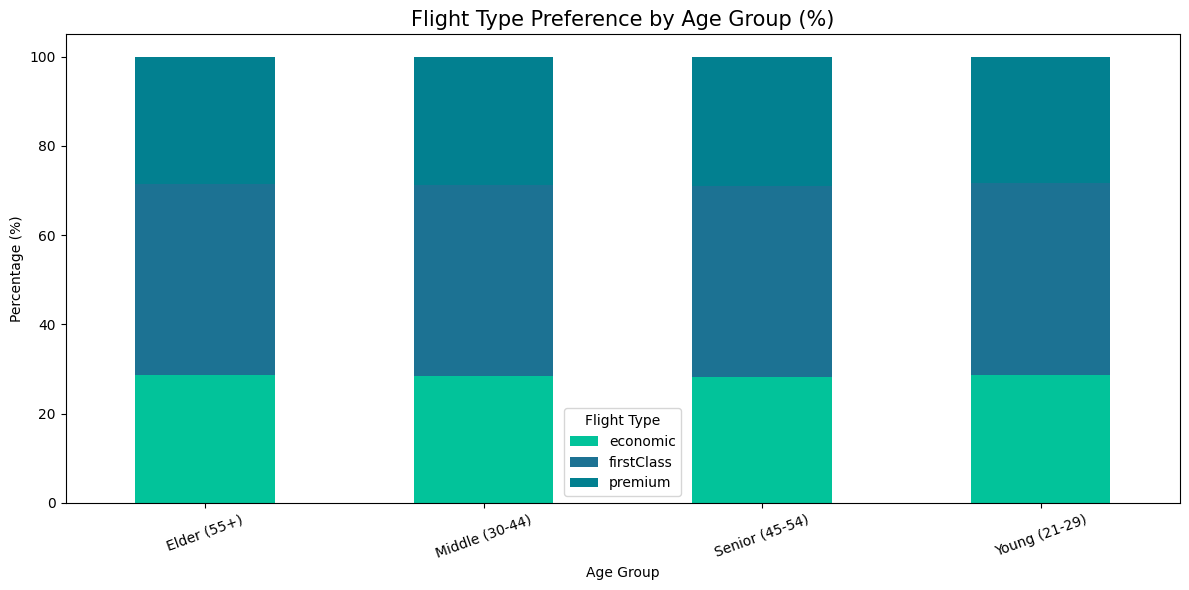

In [43]:
# Chart - 12 visualization code
# Merge users with flights to analyze age group vs flight type preference
merged = df_flights.merge(df_users, left_on='userCode', right_on='code', how='left')
merged['age_group'] = merged['age'].apply(age_group)

# Cross-tabulation of age group vs flight type
ct = pd.crosstab(merged['age_group'], merged['flightType'], normalize='index') * 100
print("=== Flight Type Preference (%) by Age Group ===")
print(ct.round(2))
print()

# Stacked bar chart
ct.plot(kind='bar', stacked=True, figsize=(12, 6),
        color=['#02C39A','#1C7293','#028090'])
plt.title('Flight Type Preference by Age Group (%)', fontsize=15)
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Flight Type')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- A Stacked Bar Chart was chosen because both variables, age_group and flightType, are categorical. 
- A stacked bar normalized to 100% (using normalize='index') makes it easy to compare the proportional preference for each flight type across different age groups. 
- It simultaneously shows composition and comparison, which a side-by-side grouped bar or a pie chart per group would not achieve as cleanly. The cross-tabulation printed above the chart adds numerical precision.

##### 2. What is/are the insight(s) found from the chart?

- All four age groups show a nearly identical distribution, approximately Economic ~29%, First Class ~42%, Premium ~29%
- There is virtually no difference in flight type preference across age groups — Elder, Middle, Senior, and Young all behave the same way
- First Class is the dominant choice in every single age group, mirroring the overall platform-wide distribution from Chart 1
- Economic and Premium shares are almost equal in every group

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- First Class dominance across all ages means premium upsell campaigns can be deployed universally without needing age-specific targeting
- Consistent behavior simplifies ML model design, age group alone is not a differentiating feature

Negative:

- Age is essentially a useless segmentation variable for flight class targeting, the platform cannot personalize flight type recommendations based on age
- This uniformity may indicate that class choice is driven by company travel policy (since all users are corporate), not personal preference, limiting the scope for individual-level personalization

#### Chart - 13 - Monthly Booking Trend (Univariate - Time Series)

   month_name  bookings
0         Jan     25587
1         Feb     22387
2         Mar     22741
3         Apr     22607
4         May     20968
5         Jun     19061
6         Jul     20113
7         Aug     17866
8         Sep     19468
9         Oct     28980
10        Nov     25764
11        Dec     26346



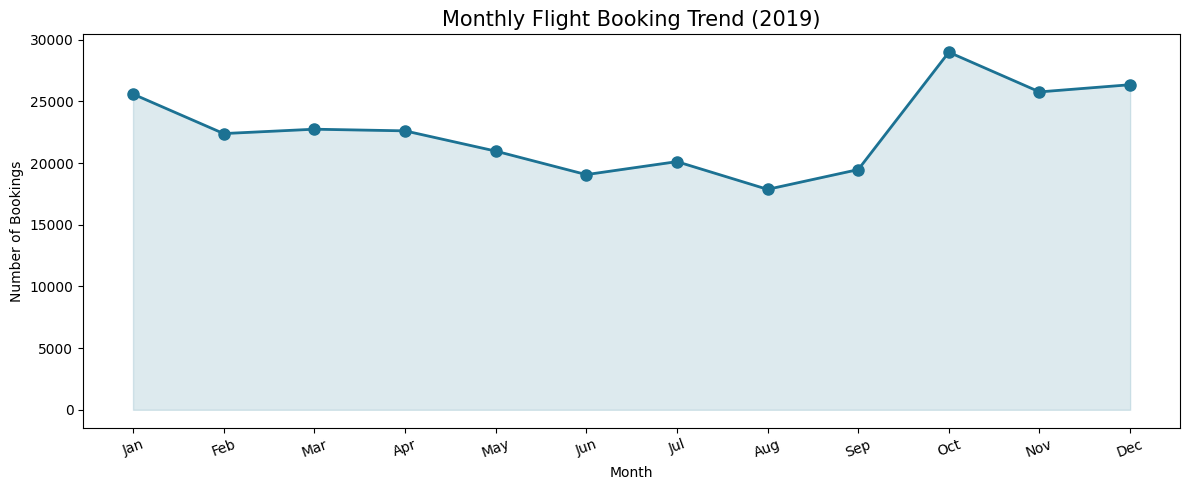

In [44]:
# Chart - 13 visualization code
# Monthly booking trend for flights
monthly = df_flights.groupby('month').size().reset_index(name='bookings')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

print(monthly[['month_name','bookings']])
print()

plt.figure(figsize=(12, 5))
plt.plot(monthly['month_name'], monthly['bookings'], marker='o',
         color='#1C7293', linewidth=2, markersize=8)
plt.fill_between(monthly['month_name'], monthly['bookings'], alpha=0.15, color='#1C7293')
plt.title('Monthly Flight Booking Trend (2019)', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- A Line Chart with Area Fill was chosen because the data is a time series, number of bookings aggregated by month across 2019. 
- Line charts are the standard visualization for time-series data as they naturally convey trends, peaks, and dips over time. 
- The filled area below the line adds visual weight, making fluctuations easier to perceive at a glance. Markers at each month highlight exact data points.

##### 2. What is/are the insight(s) found from the chart?

- January starts high (~25,600 bookings), strong post-holiday travel demand
- Bookings gradually decline from January through August, hitting the lowest point in August (~18,000)
- A sharp spike in October brings the highest bookings of the year (~28,700), the single biggest month
- November (~25,700) and December (~26,200) remain elevated, forming a strong Q4 recovery
- Mid-year months (June–August) are consistently the weakest, likely Brazil's winter season

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- October's spike and strong Q4 are predictable patterns, the airline can plan maximum capacity, staffing, and dynamic premium pricing for this period
- The seasonal trend is a highly valuable time-based feature for ML flight price prediction models

Negative:

- June through August show a sustained slump (~19,000–20,000 bookings), significant underutilization of capacity for three consecutive months
- Revenue is heavily back-loaded toward Q4, making the business vulnerable if any disruption hits October-December

#### Chart - 14 - Correlation Heatmap (Multivariate)

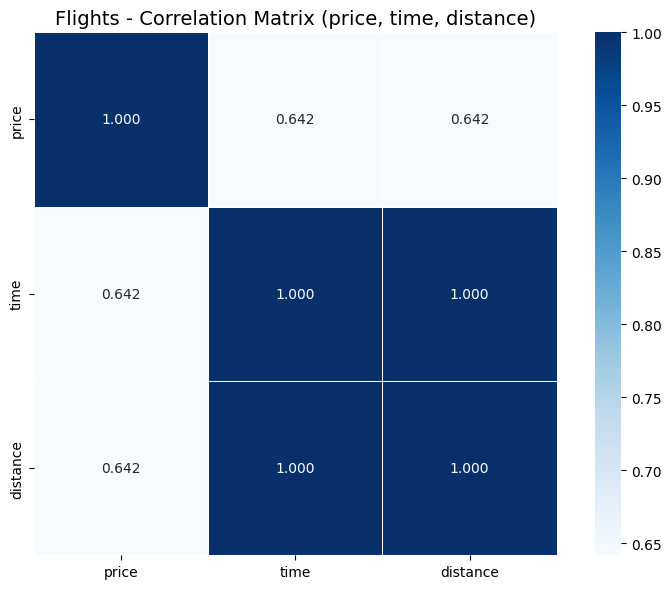

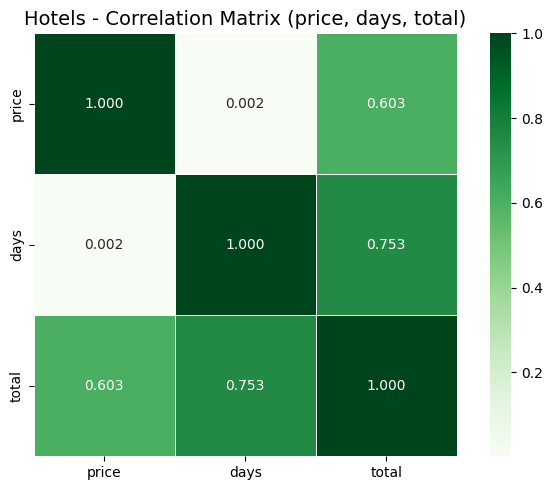

In [45]:
# Chart - 14 visualization code
# Correlation heatmap for numerical columns
num_cols_flights = ['price', 'time', 'distance']
corr_flights = df_flights[num_cols_flights].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_flights, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, square=True)
plt.title('Flights - Correlation Matrix (price, time, distance)', fontsize=14)
plt.tight_layout()
plt.show()

num_cols_hotels = ['price','days','total']
corr_hotels = df_hotels[num_cols_hotels].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_hotels, annot=True, fmt='.3f', cmap='Greens',
            linewidths=0.5, square=True)
plt.title('Hotels - Correlation Matrix (price, days, total)', fontsize=14)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- A Heatmap of the correlation matrix was chosen because it is the most compact and readable way to display pairwise correlations across multiple numerical variables simultaneously. 
- For the flights dataset (price, time, distance) and hotels dataset (price, days, total), a heatmap annotated with exact correlation values gives both a visual gradient signal and numerical precision in a single chart. 
- It is ideal for quickly identifying which variable pairs have strong, weak, or negligible relationships before building ML models.

##### 2. What is/are the insight(s) found from the chart?

- The time and distance have a perfect correlation of 1.000, they are essentially the same variable (longer routes always take longer)
- The price correlates with both time and distance at 0.642, a moderate positive relationship, meaning longer/farther flights do tend to cost more, but it's not a strong determinant
- The price and days have a near-zero correlation of 0.002, nightly price and length of stay are completely independent
- The total correlates with price at 0.603 and with days at 0.753, both contribute to total cost, but stay duration has a slightly stronger influence
- The days being a stronger driver of total than price (0.753 vs 0.603) means how long you stay matters more than which hotel you pick for total spend

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- The 0.642 correlation means distance/time can be used as a useful feature in flight price prediction ML models alongside flight class
- Since time and distance are perfectly correlated, only one needs to be included as a model feature — reducing redundancy
- The strong days → total relationship (0.753) means the platform can boost total revenue more effectively by encouraging longer stays than by pushing expensive hotels
- Promotions like "Book 3 nights, get a discount" would be more impactful than "Upgrade your hotel"

Negative:

- With only 0.642 correlation, distance alone cannot explain price, the model still needs class, agency, and route as additional features
- The perfect time-distance correlation means the dataset offers no independent signal from these two variables — it's effectively one feature, not two
- Near-zero price-days correlation confirms customers choose stay duration independently of hotel price — budget hotel customers stay just as long as premium ones, making it hard to create length-based upsell funnels for premium properties

#### Chart - 15 - Pair Plot - Flights (Multivariate)

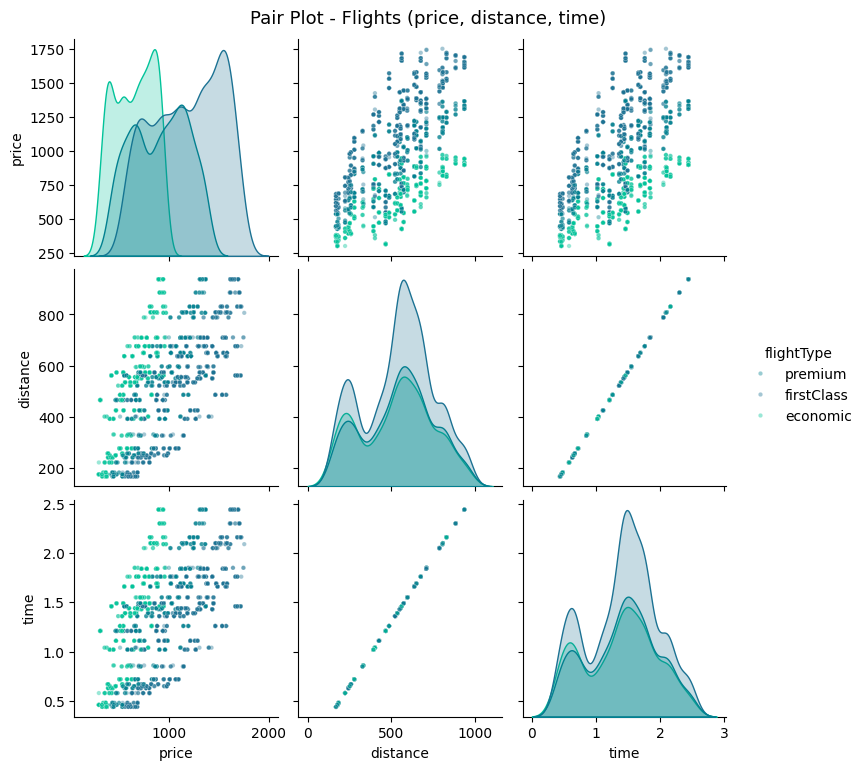

In [46]:
# Chart - 15 visualization code
# Pair plot of key numerical flight features colored by flight type
sample = df_flights.sample(3000, random_state=42)
sns.pairplot(sample[['price','distance','time','flightType']],
             hue='flightType',
             palette={'economic':'#02C39A','premium':'#028090','firstClass':'#1C7293'},
             plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pair Plot - Flights (price, distance, time)', y=1.02, fontsize=13)
plt.show()

##### 1. Why did you pick the specific chart?

- A Pair Plot (Seaborn pairplot) was chosen because it provides an all-in-one multivariate view of relationships between all pairs of numerical variables (price, distance, time) while coloring by flightType. 
- It simultaneously shows scatter plots for every variable pair and distribution histograms along the diagonal, making it the most efficient single visualization for a broad exploratory overview of numerical features. 
- A sample of 3,000 rows is used to keep rendering fast without losing the overall pattern.

##### 2. What is/are the insight(s) found from the chart?

- distance vs time shows a perfect diagonal line, confirming their 1.000 correlation; they are completely interchangeable variables
- price vs distance and price vs time show upward-trending scattered clouds, consistent with the 0.642 correlation seen in Chart 14a; higher distance/time flights do tend to cost more, but with wide spread
- The diagonal KDE plots show price has a multimodal distribution (three overlapping peaks per class), distance and time are bimodal (two distance/duration clusters visible)
- Flight type colors overlap significantly in price-distance and price-time plots, all three classes span similar distance ranges, but at different price levels

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive:

- The upward trend in price-distance confirms distance is a valid pricing input, the ML model can use it meaningfully
- The bimodal distance/time distributions suggest two distinct route categories (short-haul and long-haul), the airline can create distinct pricing strategies for each

Negative:

- Heavy overlap between flight classes in distance plots means class alone cannot distinguish short vs long routes, route distance must be an explicit model feature
- Since time and distance are perfectly collinear, including both in a model would cause multicollinearity issues

#### Chart - 16 to 20 — Agency, Hotel & User Combined Analysis (Bivariate & Multivariate)

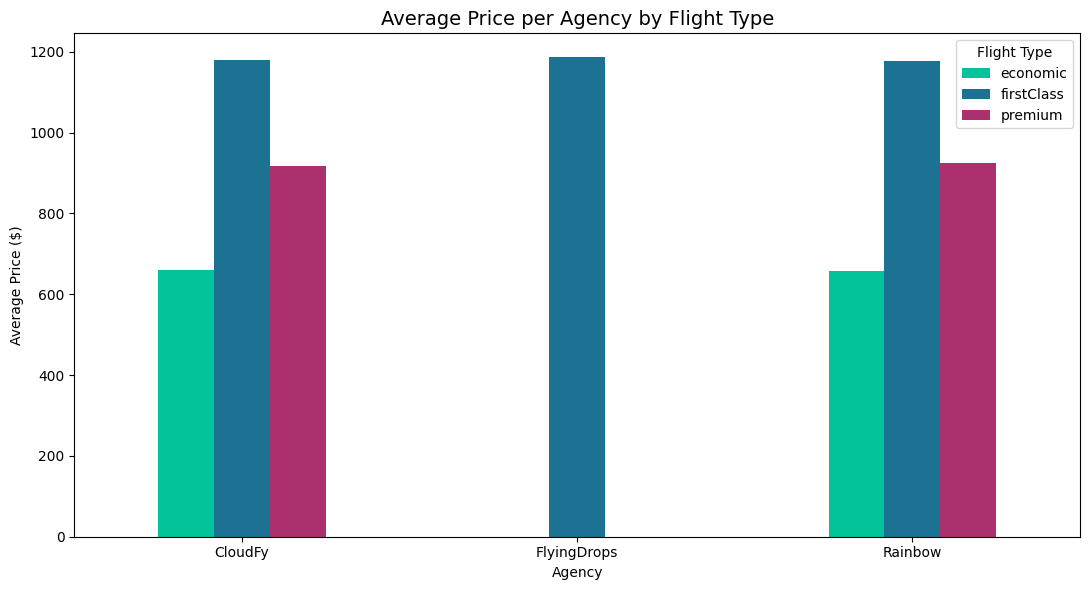

flightType   economic  firstClass  premium
agency                                    
CloudFy        658.89     1180.29   916.13
FlyingDrops       NaN     1186.16      NaN
Rainbow        658.00     1176.76   924.62


In [48]:
# Chart - 16: Average Price per Agency per Flight Type (Grouped Bar)
agency_type_price = df_flights.groupby(['agency','flightType'])['price'].mean().unstack()
agency_type_price.plot(kind='bar', figsize=(11, 6),
                       color=['#02C39A','#1C7293',"#AC306E"])
plt.title('Average Price per Agency by Flight Type', fontsize=14)
plt.xlabel('Agency')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.legend(title='Flight Type')
plt.tight_layout()
plt.show()

print(agency_type_price.round(2))

##### Charts 16 - Insights

- All three agencies charge virtually identical prices for each flight class — First Class ~$1,180–1,190, Premium ~$920–930, Economic ~$660 across CloudFy, FlyingDrops, and Rainbow
- FlyingDrops has no Economic class bar, it does not sell Economy tickets at all, only First Class (~$1,190)
- The price difference between agencies for the same class is less than $10, pricing is fully standardized
- Agency is a distribution channel, not a price differentiator

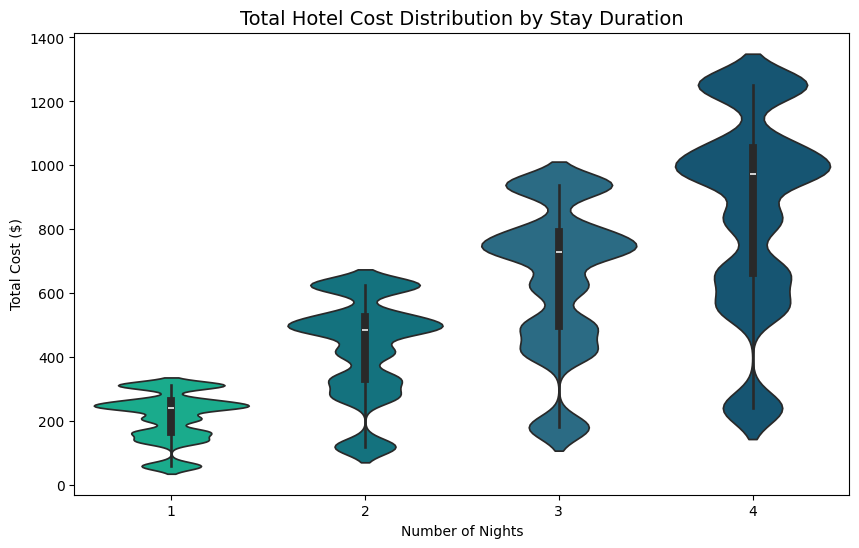

In [49]:
# Chart - 17: Total Hotel Cost by Number of Days - Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_hotels, x='days', y='total',
               palette=['#02C39A','#028090','#1C7293','#065A82'])
plt.title('Total Hotel Cost Distribution by Stay Duration', fontsize=14)
plt.xlabel('Number of Nights')
plt.ylabel('Total Cost ($)')
plt.show()

##### Chart 17 - Insights

- Total cost distributions widen and shift upward progressively from 1 to 4 nights, exactly as expected
- Each violin has a multi-modal (lumpy) shape rather than smooth, reflecting the discrete hotel price tiers (Hotels A through BW at different price points)
- 1-night stays cluster tightly around $150–$300; 4-night stays spread broadly from $200 to $1,350
- The medians (white dots) progress roughly as: 1-night ~$225, 2-night ~$475, 3-night ~$725, 4-night ~$950 — a near-linear increase

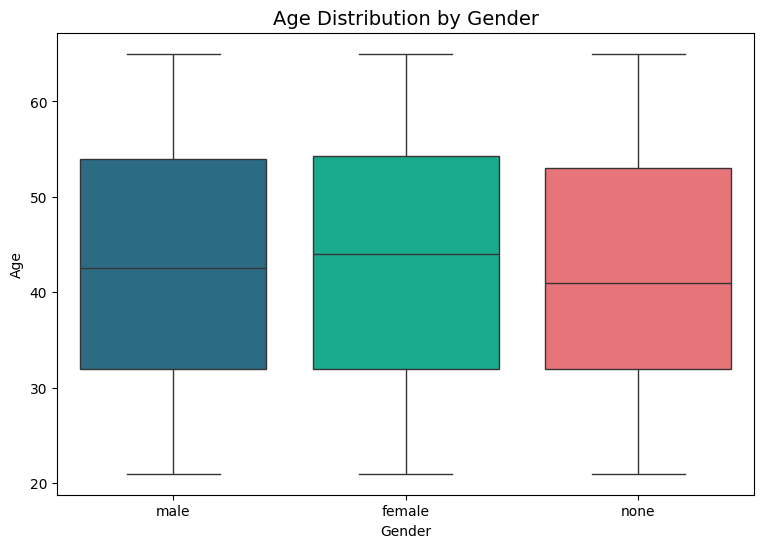

             mean  median
gender                   
female  43.180804    44.0
male    42.703540    42.5
none    42.336364    41.0


In [50]:
# Chart - 18: Age Distribution by Gender - Box Plot
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_users, x='gender', y='age',
            palette=['#1C7293','#02C39A','#F96167'])
plt.title('Age Distribution by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

print(df_users.groupby('gender')['age'].agg(['mean','median']))

##### Chart 18 - Insights

- All three gender groups span the same age range (~21–65)
- Male median age ~42, Female median age ~44, None median age ~40
- The IQRs are all wide (~32–54) and heavily overlapping across genders, virtually no age-gender relationship
- "None" group has a slightly lower median (~40) and a slightly tighter upper range (~53) compared to Male and Female

=== Average Nightly Price by Hotel ===
name
Hotel A     313.02
Hotel AU    312.83
Hotel K     263.41
Hotel BP    247.62
Hotel BD    242.88
Hotel Z     208.04
Hotel CB    165.99
Hotel AF    139.10
Hotel BW     60.39
Name: price, dtype: float64



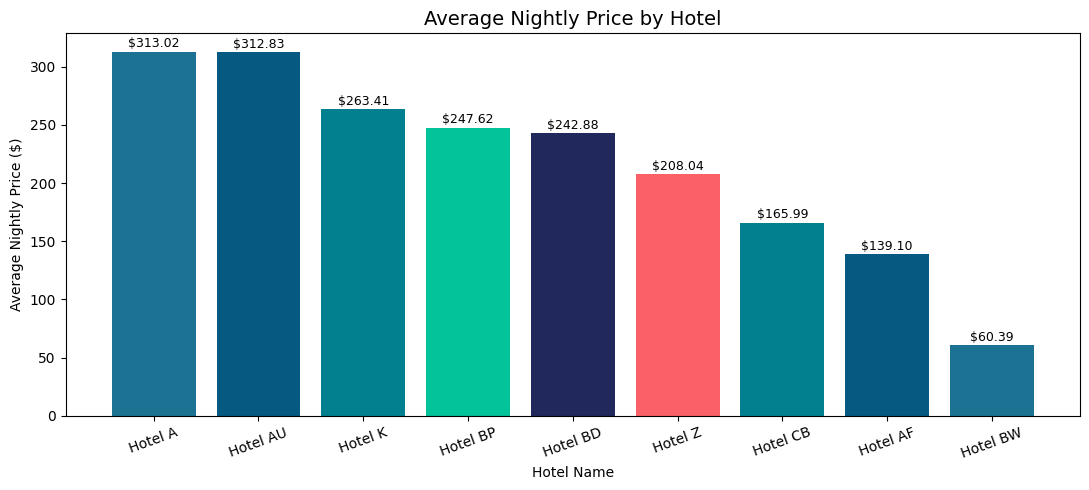

In [51]:
# Chart - 19: Top 5 Most Expensive Hotels - Bar Chart
hotel_price = df_hotels.groupby('name')['price'].mean().sort_values(ascending=False)
print("=== Average Nightly Price by Hotel ===")
print(hotel_price.round(2))
print()

plt.figure(figsize=(11, 5))
bars = plt.bar(hotel_price.index, hotel_price.values,
               color=['#1C7293','#065A82','#028090','#02C39A','#21295C','#F96167','#028090','#065A82','#1C7293'])
for bar, val in zip(bars, hotel_price.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'${val:.2f}',
             ha='center', va='bottom', fontsize=9)
plt.title('Average Nightly Price by Hotel', fontsize=14)
plt.xlabel('Hotel Name')
plt.ylabel('Average Nightly Price ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### Chart 19 - Insights

- Hotel A ($313.02) and Hotel AU ($312.83) are the clear premium tier, nearly identical and well above the rest
- Hotel K ($263.41), Hotel BP ($247.62), Hotel BD ($242.88) form an upper-mid tier
- Hotel Z ($208.04) marks the beginning of a budget mid-range
- Hotel CB ($165.99) and Hotel AF ($139.10) are budget options
- Hotel BW ($60.39) is an extreme outlier at the bottom, priced nearly 5x cheaper than Hotel A, suggesting it may be a very basic or short-stay accommodation

=== Average Flight Price by Age Group ===
        age_group    mean  median
0     Elder (55+)  952.12  898.67
1  Middle (30-44)  959.57  904.66
2  Senior (45-54)  954.11  898.67
3   Young (21-29)  963.53  908.17



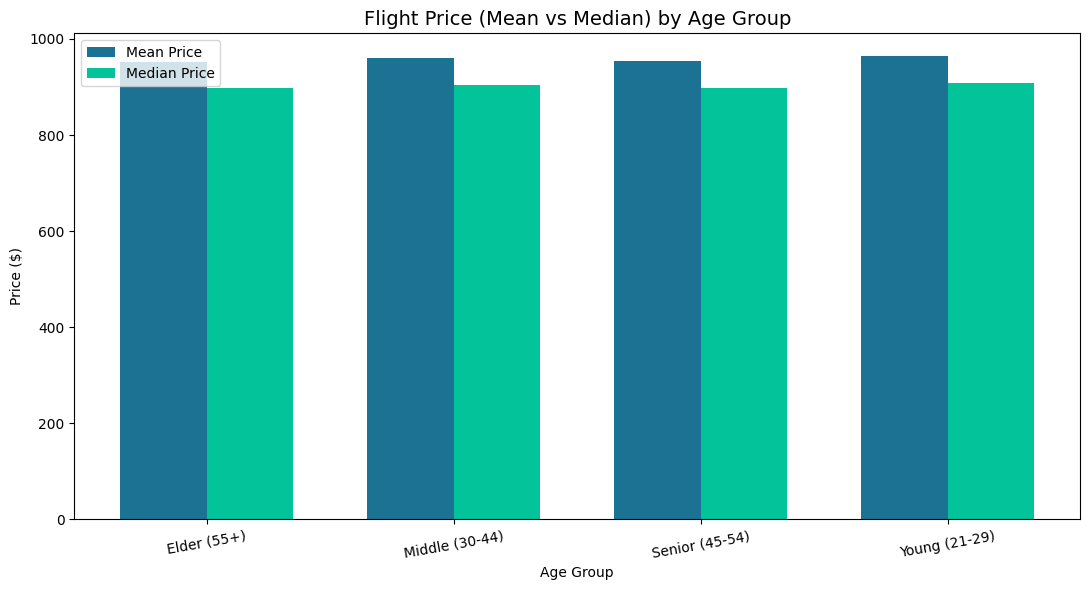

In [52]:
# Chart - 20: Flight Price vs Age Group (Bivariate: Numerical-Categorical) - Combined
merged_full = df_flights.merge(df_users, left_on='userCode', right_on='code', how='left')
merged_full['age_group'] = merged_full['age'].apply(age_group)

age_price = merged_full.groupby('age_group')['price'].agg(['mean','median']).reset_index()
print("=== Average Flight Price by Age Group ===")
print(age_price.round(2))
print()

x = range(len(age_price))
width = 0.35
plt.figure(figsize=(11, 6))
plt.bar([i - width/2 for i in x], age_price['mean'],   width, label='Mean Price',   color='#1C7293')
plt.bar([i + width/2 for i in x], age_price['median'], width, label='Median Price', color='#02C39A')
plt.xticks(x, age_price['age_group'], rotation=10)
plt.title('Flight Price (Mean vs Median) by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

##### Chart 20 - Insights

- Mean and Median prices are nearly identical across all four age groups -> Mean ~$895–965, Median ~$900 for all groups
- The difference between the highest and lowest mean across age groups is less than $70, statistically negligible
- Middle (30–44) has the highest mean (~$960), but the difference from other groups is minimal
- All medians are virtually the same (~$900), confirming age has no influence on flight price paid

## **5. Solution to Business Objective**


#### What do you suggest the client to achieve Business Objective?
Explain Briefly.

**1. Build a Two-Factor Flight Price Prediction Model**

The EDA revealed that flight price is driven by two things -> flight class and route distance (correlation: 0.642). A price prediction ML model should use flightType as the primary categorical feature and distance (or time, since they are perfectly correlated at 1.000) as the numerical feature. Agency can be dropped from the model since all three agencies charge identical prices for the same class. This model will directly serve the goal of predicting flight prices for smarter booking recommendations.

**2. Strengthen Partnerships with Rainbow and CloudFy**

These two agencies control ~87% of all bookings. The client should formalize data-sharing agreements and co-marketing arrangements with both. At the same time, FlyingDrops, which only sells First Class and holds just ~14% market share, should either be encouraged to expand into Economy and Premium tiers or be replaced by a more versatile third agency to reduce duopoly risk.

**3. Develop a Hotel Recommendation Engine Focused on Premium Tier**

Chart 7 showed that the highest-priced hotels (Hotel A at $313 and Hotel AU at $313) are also the most frequently booked. The client should prioritize these premium properties in their recommendation engine. Additionally, the platform has visible pricing gaps between $80–$120 and $170–$195, adding hotels in these price bands would capture customers currently leaving the platform without booking.

**4. Implement Seasonal Capacity and Pricing Strategy**

Chart 13 clearly showed that October is the peak booking month (~28,700 bookings) while August is the weakest (~18,000). The client should apply dynamic pricing, higher fares in October–December, promotional discounts in June–August, to smooth demand and maximize revenue year-round. This seasonal pattern is also a strong feature for any time-series ML model.

**5. Encourage Longer Hotel Stays Through Incentives**

Chart 14b showed that the number of nights stayed (0.753) is a stronger driver of total hotel revenue than nightly price (0.603). This means the most effective revenue growth lever for the hotel segment is duration, not price. The client should introduce multi-night bundled deals (e.g., "Book 3 nights, get 10% off") to shift bookings from 1-night to 3–4 night stays and increase per-customer revenue.

**6. Address 4You Dependency Risk**

Chart 11 revealed that 4You alone contributes 453 users, 34% of the entire platform. While this is a key revenue relationship to nurture with dedicated corporate dashboards and priority service, the client must simultaneously onboard new corporate clients to reduce this single-point-of-failure risk. Targeting companies of similar size to Acme Factory (261) and Wonka Company (237) is the most realistic near-term growth path.

**7. Rely on Behavioral Data, Not Demographics, for Personalization**

Charts 12, 18, 20 all confirmed the same finding -> age group, gender, and age have virtually no influence on flight class preference or price paid. The platform's users are a homogeneous corporate demographic. For effective ML-powered personalization, the client should enrich the dataset with behavioral signals, booking frequency, repeat routes, cancellation history, upgrade patterns, rather than relying on demographic variables.

# **Conclusion**


- This EDA analyzed a Brazilian corporate travel platform - Voyage Analytics, covering 271,888 flight records, 40,552 hotel bookings, and 1,340 user profiles from 2019. The data was clean with no missing or duplicate values across all three datasets, though the near-perfect uniformity in hotel stay durations and user age distribution suggests the data may have been synthetically generated, which should be kept in mind when building production ML models.

- **On Flights**: The platform is dominated by First Class bookings (~43%), with Premium and Economic classes nearly equally split (~28.5% each). Three agencies serve the market, Rainbow and CloudFy together control 87% of bookings, while FlyingDrops is limited exclusively to First Class tickets. Flight pricing is driven by a combination of flight class and route distance (correlation: 0.642), while time and distance are perfectly interchangeable (correlation: 1.000). Florianopolis and Salvador emerged as the two highest-value route hubs, consistently appearing in the top 10 most expensive corridors. Seasonal analysis showed October as the peak month and August as the weakest, a clear pattern for capacity and pricing planning.

- **On Hotels**: The platform lists 9 hotels with nightly prices ranging from $60.39 (Hotel BW) to $313.02 (Hotel A). Interestingly, the most expensive hotels are also the most frequently booked, confirming a premium-leaning customer base. Hotel stay durations are perfectly uniformly distributed across 1–4 nights, and nightly price has virtually no relationship with how long customers stay (correlation: 0.002). Total hotel cost is more strongly influenced by stay duration (0.753) than by nightly price (0.603), a key insight for revenue optimization.

- **On Users**: All 1,340 users belong to just 5 companies, making this a fully B2B platform. 4You dominates with 453 users. Gender is evenly split across Male (33.7%), Female (33.4%), and Not Specified (32.8%). The user age range is 21–65 with a Mean of 42.7 years and Median of 42 years, a flat, working-age distribution. Critically, neither age group, gender, nor age meaningfully differentiates flight class preference or price paid, all demographic segments behave almost identically, pointing to corporate travel policy as the dominant driver of booking decisions rather than individual preference.

- Overall, Voyage Analytics sits on a well-structured, clean dataset with clear pricing patterns, identifiable seasonal trends, and strong premium market demand. The most impactful next steps are building a class-and-distance based flight price prediction model, developing a hotel recommendation engine anchored on premium properties, implementing seasonal dynamic pricing, and enriching the dataset with behavioral features to unlock meaningful personalization, moving the platform from a data-aware travel service to a genuinely ML-powered travel intelligence platform.